In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#!pip install tensorflow==2.12

In [3]:
cd /content/drive/MyDrive/Cheating_enhancement/data/data1_oep

/content/drive/MyDrive/Cheating_enhancement/data/data1_oep


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import tensorflow.keras.layers as tfl

from tensorflow.keras.preprocessing import image_dataset_from_directory
#from tensorflow.keras.layers.experimental.preprocessing import RandomFlip, RandomRotation

In [ ]:
!pwd

In [5]:
# Imports (kept same as previous)
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input, Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, GlobalMaxPooling2D, Reshape, multiply, add, Permute, Concatenate, Activation, Lambda, AveragePooling2D
from tensorflow.keras import callbacks
from tensorflow.keras import backend as K
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Define SE and CBAM blocks (same as previous code)
def channel_attention(input_feature, ratio=8):
    channel_axis = -1 if K.image_data_format() == 'channels_last' else 1
    channel = input_feature.shape[channel_axis]

    shared_layer_one = Dense(channel // ratio, activation='relu', kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')
    shared_layer_two = Dense(channel, kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')

    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_layer_one(avg_pool)
    avg_pool = shared_layer_two(avg_pool)

    max_pool = GlobalMaxPooling2D()(input_feature)
    max_pool = Reshape((1, 1, channel))(max_pool)
    max_pool = shared_layer_one(max_pool)
    max_pool = shared_layer_two(max_pool)

    cbam_feature = add([avg_pool, max_pool])
    cbam_feature = Activation('sigmoid')(cbam_feature)

    return multiply([input_feature, cbam_feature])

def spatial_attention(input_feature):
    kernel_size = 7
    avg_pool = Lambda(lambda x: tf.keras.backend.mean(x, axis=3, keepdims=True))(input_feature)
    max_pool = Lambda(lambda x: tf.keras.backend.max(x, axis=3, keepdims=True))(input_feature)
    concat = Concatenate(axis=3)([avg_pool, max_pool])

    cbam_feature = Conv2D(filters=1, kernel_size=kernel_size, strides=1, padding='same', activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(concat)
    if K.image_data_format() == "channels_first":
        cbam_feature = Permute((3, 1, 2))(cbam_feature)

    return multiply([input_feature, cbam_feature])

def cbam_block(cbam_feature, ratio=8):
    cbam_feature = channel_attention(cbam_feature, ratio)
    cbam_feature = spatial_attention(cbam_feature)
    return cbam_feature

def se_block(input_feature, ratio=16):
    channel_axis = -1 if K.image_data_format() == 'channels_last' else 1
    channels = input_feature.shape[channel_axis]
    se_shape = (1, 1, channels)

    se = GlobalAveragePooling2D()(input_feature)
    se = Reshape(se_shape)(se)
    se = Dense(channels // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(channels, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)

    return multiply([input_feature, se])


In [6]:
#BATCH_SIZE = 32
BATCH_SIZE = 16
IMG_SIZE = [224, 224]
directory = "/content/drive/MyDrive/Cheating_enhancement/data/data1_oep"

In [7]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense

# Setup directory paths and parameters
directory = "/content/drive/MyDrive/Cheating_enhancement/data/data1_oep"
BATCH_SIZE = 16
IMG_SIZE = (224, 224)

In [8]:
# Load datasets
train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.3,  # 30% for validation
                                             subset='training',
                                             seed=42)

validation_dataset = image_dataset_from_directory(directory,
                                                  shuffle=True,
                                                  batch_size=BATCH_SIZE,
                                                  image_size=IMG_SIZE,
                                                  validation_split=0.2,  # 20% for validation
                                                  subset='validation',
                                                  seed=42)

test_dataset = image_dataset_from_directory(directory,
                                            shuffle=True,
                                            batch_size=BATCH_SIZE,
                                            image_size=IMG_SIZE,
                                            validation_split=0.1,  # 10% for testing
                                            subset='validation',
                                            seed=42)

Found 11581 files belonging to 2 classes.
Using 8107 files for training.
Found 11581 files belonging to 2 classes.
Using 2316 files for validation.
Found 11581 files belonging to 2 classes.
Using 1158 files for validation.


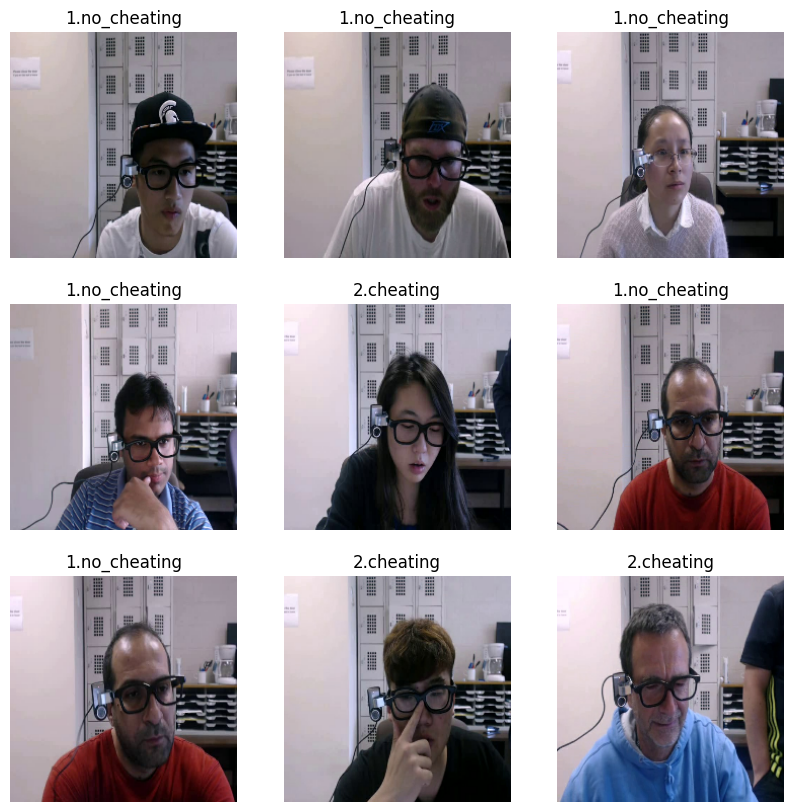

In [9]:
# Display some images
class_names = train_dataset.class_names
num_classes = len(class_names)  # Number of classes
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


In [ ]:
print(class_names)

['1.no_cheating', '2.cheating']


In [10]:
# Define the custom model with SE and CBAM blocks
input_tensor = Input(shape=(224, 224, 3))

# Initial Conv Layer with fewer filters to reduce complexity
x = Conv2D(filters=64, kernel_size=(3, 3), activation='elu', padding='same', kernel_initializer='he_normal')(input_tensor)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# Reduced convolutional blocks with attention modules
x = Conv2D(filters=128, kernel_size=(3, 3), activation='elu', padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = se_block(x)  # Using SE Block
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)

x = Conv2D(filters=128, kernel_size=(3, 3), activation='elu', padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = cbam_block(x)  # Using CBAM Block
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)

# Only using CBAM and SE in alternate layers to reduce redundancy
x = Conv2D(filters=256, kernel_size=(3, 3), activation='elu', padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)

# Final layers
x = Flatten()(x)
x = Dense(128, activation='elu', kernel_initializer='he_normal')(x)  # Reduced dense units
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output_tensor = Dense(1, activation='sigmoid')(x)

# Model definition
model = Model(inputs=input_tensor, outputs=output_tensor)


In [11]:
# Compile the model for binary classification
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=['accuracy'])


In [ ]:
# Callbacks for training
# Train the model
import time
t1 = time.time()
initial_epochs = 60
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=initial_epochs)
t2 = time.time()
print(f"Training time: {t2 - t1} seconds")

Epoch 1/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 446s 845ms/step - accuracy: 0.7467 - loss: 0.5608 - val_accuracy: 0.8856 - val_loss: 0.2850
Epoch 2/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.8643 - loss: 0.3342 - val_accuracy: 0.9167 - val_loss: 0.2246
Epoch 3/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.8971 - loss: 0.2728 - val_accuracy: 0.9227 - val_loss: 0.2147
Epoch 4/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.8986 - loss: 0.2572 - val_accuracy: 0.6684 - val_loss: 0.6451
Epoch 5/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9111 - loss: 0.2354 - val_accuracy: 0.7910 - val_loss: 0.4443
Epoch 6/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9185 - loss: 0.2294 - val_accuracy: 0.8985 - val_loss: 0.2780
Epoch 7/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9205 - loss: 0.2169 - val_accuracy: 0.9184 - val_loss: 0.2321
Epoch 8/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9331 - loss: 0.1849 

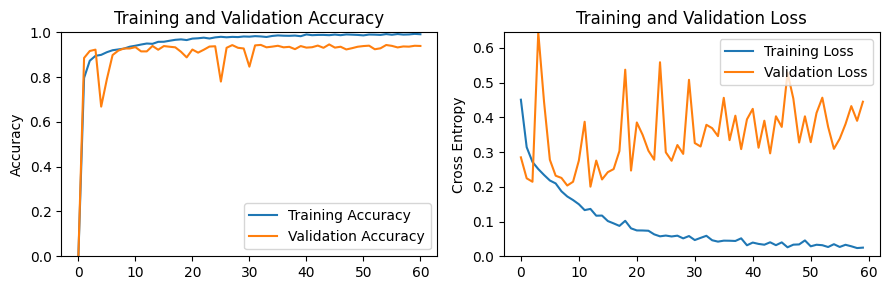

In [ ]:
# Plotting training results
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(acc, label='Training Accuracy')
ax1.plot(val_acc, label='Validation Accuracy')
ax1.legend(loc='lower right')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([min(min(acc), min(val_acc)), 1])
ax1.set_title('Training and Validation Accuracy')

ax2.plot(loss, label='Training Loss')
ax2.plot(val_loss, label='Validation Loss')
ax2.legend(loc='upper right')
ax2.set_ylabel('Cross Entropy')
ax2.set_ylim([0, max(max(loss), max(val_loss))])
ax2.set_title('Training and Validation Loss')
plt.tight_layout()
plt.show()

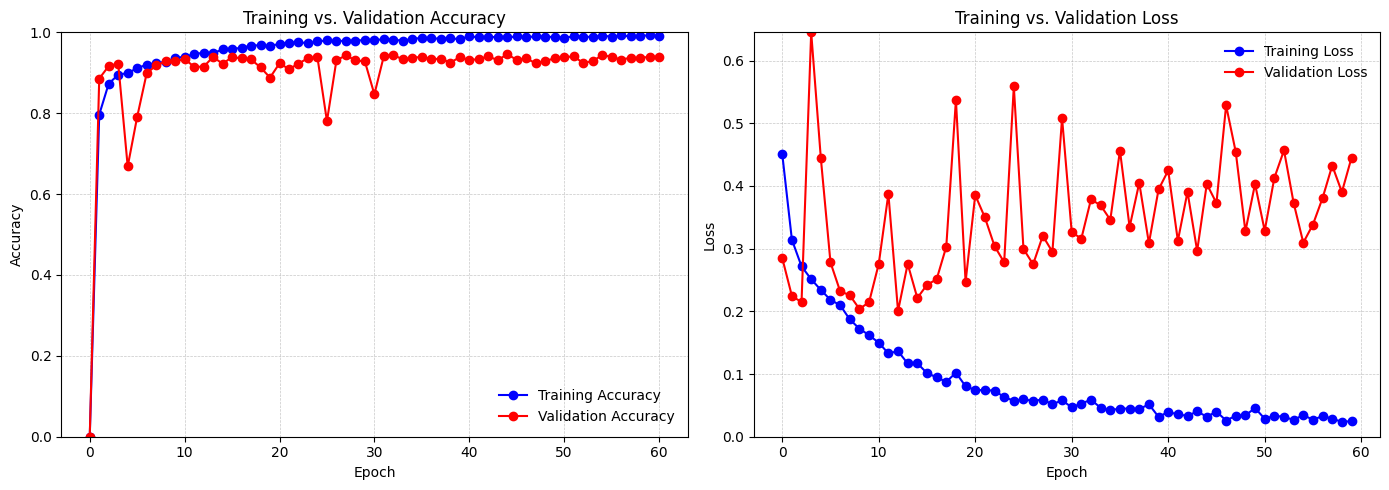

In [ ]:
import matplotlib.pyplot as plt

# Sample Data (replace with your actual history data)
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training and Validation Accuracy Plot
ax1.plot(acc, marker='o', linestyle='-', color='blue', label='Training Accuracy')
ax1.plot(val_acc, marker='o', linestyle='-', color='red', label='Validation Accuracy')
ax1.legend(loc='lower right', fontsize=10, frameon=False)  # Legend inside the plot, lower right
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([min(min(acc), min(val_acc)), 1])
ax1.set_title('Training vs. Validation Accuracy')
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  # Light grid lines

# Training and Validation Loss Plot
ax2.plot(loss, marker='o', linestyle='-', color='blue', label='Training Loss')
ax2.plot(val_loss, marker='o', linestyle='-', color='red', label='Validation Loss')
ax2.legend(loc='upper right', fontsize=10, frameon=False)  # Legend inside the plot, upper right
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_ylim([0, max(max(loss), max(val_loss))])
ax2.set_title('Training vs. Validation Loss')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  # Light grid lines

# Adjust layout and background color
fig.patch.set_facecolor('white')  # Set figure background to white
fig.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to fit everything nicely
plt.show()


In [ ]:
# Evaluate the model on the training dataset
train_loss, *train_metrics = model.evaluate(train_dataset)
print("Training Loss:", train_loss)
print("Training Metrics:", train_metrics)

# Evaluate the model on the validation dataset
val_loss, *val_metrics = model.evaluate(validation_dataset)
print("Validation Loss:", val_loss)
print("Validation Metrics:", val_metrics)


507/507 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9955 - loss: 0.0121
Training Loss: 0.009457514621317387
Training Metrics: [0.9962995052337646]
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9348 - loss: 0.4533
Validation Loss: 0.4451984465122223
Validation Metrics: [0.9391191601753235]


In [ ]:
import time

# Start the timer
t3 = time.time()

# Evaluate the model on the test dataset
test_loss, *test_metrics = model.evaluate(test_dataset)

# End the timer
t4 = time.time()

# Calculate and print the execution time
temps_execution = t4 - t3
print(f"Le temps d'exécution est de {temps_execution} secondes.")

# Print the test loss and metrics
print("Test Loss:", test_loss)
print("Test Metrics:", test_metrics)


73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9392 - loss: 0.4538
Le temps d'exécution est de 3.494140625 secondes.
Test Loss: 0.5114343166351318
Test Metrics: [0.936096727848053]


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# Setup directory paths and parameters

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

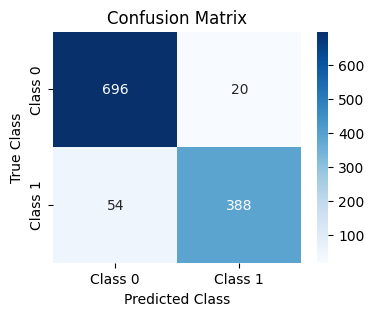

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels and predicted labels
y_true = []
y_pred = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())  # Get the true labels
    predictions = model.predict(images)  # Get model predictions
    y_pred.extend((predictions > 0.5).astype(int).flatten())  # Threshold for binary classification

# Define binary class names
class_names = ["No_Cheating", "Cheating"]

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(4, 3))  # Set the figure size to 3x4
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()


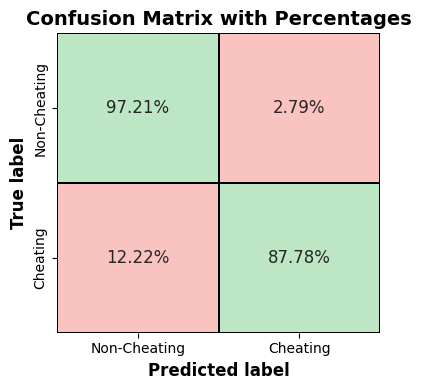

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming conf_matrix is defined elsewhere in your code
f, ax = plt.subplots(figsize=(4, 4))  # Adjust the figure size to be 4x4 for compactness

# Calculate the percentages
cf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

# Create the labels with percentages
labels = [f'{value:.2f}%' for value in cf_matrix_percent.flatten()]
labels = np.asarray(labels).reshape(conf_matrix.shape)

# Define a custom color map for the background
colors = ['#BDE6C4', '#F9C4C0']

# Use the same color palette as before
cmap = sns.color_palette(colors)

# Create a mask to differentiate True Positives/Negatives and False Positives/Negatives
mask = np.array([[True, False], [False, True]])  # Mask for the red areas (False values will be colored green)

# Create the heatmap with the custom background colors
sns.heatmap(cf_matrix_percent, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#F9C4C0']), mask=mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Overlay the original confusion matrix with a separate color (green) for TP and TN
sns.heatmap(cf_matrix_percent, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#BDE6C4']), mask=~mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Set the title and labels (matching appearance from the previous code)
ax.set_title('Confusion Matrix with Percentages', fontsize=14, weight='bold')
ax.set_xlabel('Predicted label', fontsize=12, weight='bold')
ax.set_ylabel('True label', fontsize=12, weight='bold')

# Set tick labels with smaller font sizes
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)

# Ensure everything fits well
plt.tight_layout()
plt.show()


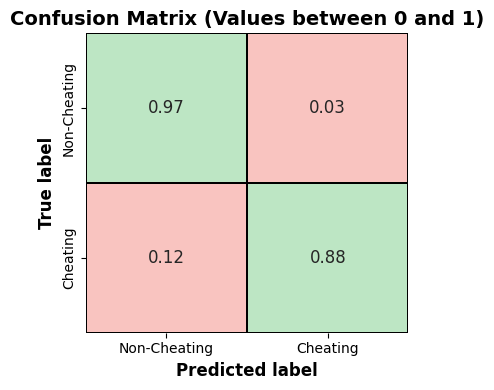

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming conf_matrix is defined elsewhere in your code
f, ax = plt.subplots(figsize=(4, 4))  # Adjust the figure size to be 4x4 for compactness

# Calculate values between 0 and 1
cf_matrix_normalized = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create labels showing values between 0 and 1
labels = [f'{value:.2f}' for value in cf_matrix_normalized.flatten()]
labels = np.asarray(labels).reshape(conf_matrix.shape)

# Define a custom color map for the background
colors = ['#BDE6C4', '#F9C4C0']

# Use the same color palette as before
cmap = sns.color_palette(colors)

# Create a mask to differentiate True Positives/Negatives and False Positives/Negatives
mask = np.array([[True, False], [False, True]])  # Mask for the red areas (False values will be colored green)

# Create the heatmap with the custom background colors
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#F9C4C0']), mask=mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Overlay the original confusion matrix with a separate color (green) for TP and TN
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#BDE6C4']), mask=~mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Set the title and labels
ax.set_title('Confusion Matrix (Values between 0 and 1)', fontsize=14, weight='bold')
ax.set_xlabel('Predicted label', fontsize=12, weight='bold')
ax.set_ylabel('True label', fontsize=12, weight='bold')

# Set tick labels with smaller font sizes
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)

# Ensure everything fits well
plt.tight_layout()
plt.show()


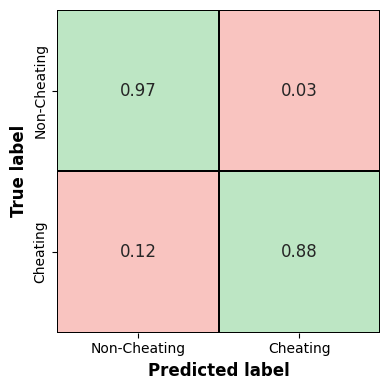

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming conf_matrix is defined elsewhere in your code
f, ax = plt.subplots(figsize=(4, 4))  # Adjust the figure size to be 4x4 for compactness

# Calculate values between 0 and 1
cf_matrix_normalized = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create labels showing values between 0 and 1
labels = [f'{value:.2f}' for value in cf_matrix_normalized.flatten()]
labels = np.asarray(labels).reshape(conf_matrix.shape)

# Define a custom color map for the background
colors = ['#BDE6C4', '#F9C4C0']

# Use the same color palette as before
cmap = sns.color_palette(colors)

# Create a mask to differentiate True Positives/Negatives and False Positives/Negatives
mask = np.array([[True, False], [False, True]])  # Mask for the red areas (False values will be colored green)

# Create the heatmap with the custom background colors
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#F9C4C0']), mask=mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Overlay the original confusion matrix with a separate color (green) for TP and TN
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#BDE6C4']), mask=~mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Set the title and labels
#ax.set_title('Confusion Matrix (Values between 0 and 1)', fontsize=14, weight='bold')
ax.set_xlabel('Predicted label', fontsize=12, weight='bold')
ax.set_ylabel('True label', fontsize=12, weight='bold')

# Set tick labels with smaller font sizes
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)

# Ensure everything fits well
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming y_true and y_pred are already defined

# Calculate accuracy, precision, recall, and f1 score
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='binary')  # Use 'binary' for binary classification, or 'macro', 'micro' for multi-class
recall = recall_score(y_true, y_pred, average='binary')
f1 = f1_score(y_true, y_pred, average='binary')

# Print the results
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


Accuracy: 0.94
Precision: 0.95
Recall: 0.88
F1 Score: 0.91


AUC for our classifier is: 0.92


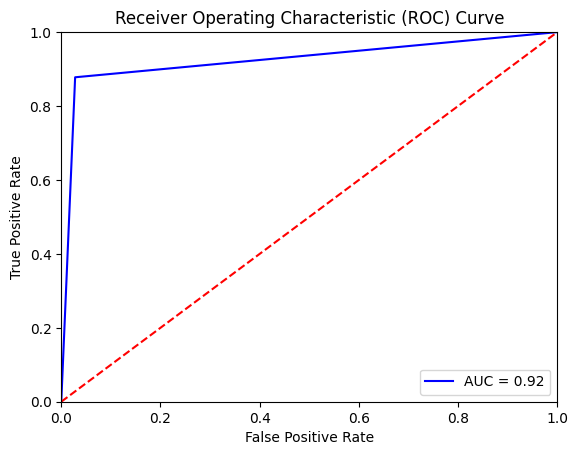

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# ROC Curve
fpr, tpr, threshold = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

# Printing AUC
print(f"AUC for our classifier is: {roc_auc:.2f}")

# Plotting the ROC curve
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.plot(fpr, tpr, 'b', label=f'AUC = {roc_auc:.2f}')
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')  # Diagonal line
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
%cd /content/drive/MyDrive/Cheating_enhancement/
# Saving the model in HDF5 format
model_save_path = 'saved_models/resNET50_CBAM_d1.h5'
model.save(model_save_path)

/content/drive/MyDrive/Cheating_enhancement


In [ ]:
import tensorflow as tf
%cd /content/drive/MyDrive/Cheating_enhancement/
# Specify the path to the saved model directory
model_path = 'saved_models/resNET50_CBAM_d1.h5'

# Load the trained model
model = tf.keras.models.load_model(model_path)

# The model is ready to use in inference mode

/content/drive/MyDrive/Cheating_enhancement


NotImplementedError: Exception encountered when calling Lambda.call().

[1mWe could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.[0m

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 56, 56, 128), dtype=float32, sparse=False, name=keras_tensor_98>',)
  • kwargs={'mask': 'None'}

In [ ]:
import time

# Initialize variables to accumulate time and count images
total_time = 0
num_images = 0

# Loop over the dataset to measure time for each image
for images, labels in test_dataset:
    start_time = time.time()
    _ = model.evaluate(images, labels, verbose=0)  # Evaluate on a single batch (1 image at a time if batch size is 1)
    end_time = time.time()

    # Accumulate time and count
    total_time += (end_time - start_time)
    num_images += images.shape[0]  # Add number of images in the batch
print(total_time )
print(f"test time: {total_time:.4f} seconds")
print('---------------------')
print( num_images)
print('---------------------')
# Calculate average time per image
average_time_per_image = total_time / num_images
print(f"Average time per image: {average_time_per_image:.4f} seconds")


In [ ]:
import time

# Assuming `model` is your loaded model
# Start timing
start_time = time.time()

# Run the model on the entire test dataset to get predictions
predictions = model.predict(test_dataset)

# End timing
end_time = time.time()


73/73 ━━━━━━━━━━━━━━━━━━━━ 228s 3s/step


NameError: name 'test_ds' is not defined

In [ ]:

# Calculate total and average time
total_time = end_time - start_time
num_images = sum(batch.shape[0] for batch, _ in test_dataset)  # Total number of images

print(f"Total inference time: {total_time:.4f} seconds")
print(f"Average time per image: {total_time / num_images:.4f} seconds")


Total inference time: 228.5463 seconds
Average time per image: 0.1974 seconds


In [ ]:
import time

# Assuming `model` is your loaded model
# Start timing
start_time = time.time()

# Run the model on the entire test dataset to get predictions
predictions = model.predict(test_dataset)

# End timing
end_time = time.time()

# Calculate total and average time
total_time = end_time - start_time
num_images = sum(batch.shape[0] for batch, _ in test_dataset)  # Total number of images

print(f"Total inference time: {total_time:.4f} seconds")
print(f"Average time per image: {total_time / num_images:.4f} seconds")


In [12]:
import time

# Limit the test dataset to the first 960 images
test_limited = test_dataset.take(960)

# Start timing
start_time = time.time()

# Run the model on the limited test dataset to get predictions
predictions = model.predict(test_limited)

# End timing
end_time = time.time()

# Calculate total and average time
total_time = end_time - start_time
num_images = 960  # Since we are only taking 960 images

print(f"Total inference time for 960 images: {total_time:.4f} seconds")
print(f"Average time per image: {total_time / num_images:.4f} seconds")

73/73 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step
Total inference time for 960 images: 202.6077 seconds
Average time per image: 0.2110 seconds
